<h1>Sum of Squares</h1>
<h3>January 2024</h3>

[Sum of Squares puzzle](https://www.janestreet.com/puzzles/sum-of-squares-index/)

<div style="text-align:center">
  <img src="IMG_4851.png" width="50%"/>
</div>

Place a digit in each of the 25 spots in the below 5×5 grid, so that each 5-digit number (leading zeroes are ok) reading across and reading down is divisible by the number outside the grid, trying to maximize the sum of the 25 numbers you enter. An example of a completed grid with sum 100 is presented on the right.

Please submit your answer (along with any other comments you want to provide) as an ordered pair of your sum, and your 25 numbers, reading left to right, top to bottom.

Example submission: (100,1623552460048932486847030)
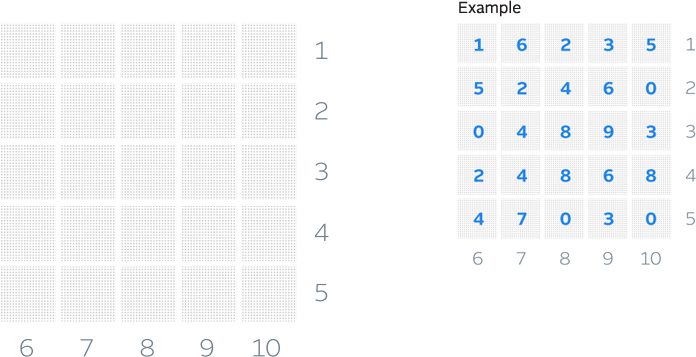

## Solution

There are $25^{10} \approx 10^{14}$ possible combinations. Assuming we could process $10^6$ combinations per second, it would still take $10^8$ seconds or 3.17 years which is unfeasible.

A first approach would be to do a Depth First Search (DFS) with backtracking and pruning. In this approach, each branch of solutions is explored fully by adding one digit at a time, until a solution becomes unfeasible at which point we backtrack and prune, i.e. discard, the remaining branch.
This approach is also very time-consuming because we must discover all viable branches in order to be sure we have found the optimal solution that maximises the objective.

The best approach which leads to the answer within minutes is to use a max-head to dynamically construct combinations with decreasing total sum, stopping when we find the first valid combination.
This approach ensures that the first valid combination will be the one with the maximum sum by construction.

Before we begin, there are a number of constraints that reduce the state space we need to consider.

The heap structure and additional notions required to understand the solution are provided in the `heap_tutorial.ipynb`.

### Cell Constrains

Divisibility rules.


|Divisor | Rule                                                                                    |
|-|-----------------------------------------------------------------------------------------|
| 1 | No constraint                                                                           |
| 2 | Last digit is divisible by 2                                                            |
| 3 | Sum of digits is divisible by 3                                                         |
| 4 | Last two digits are divisible by 4                                                      |
| 5 | Last digit is 0 or 5                                                                    |
|6 | Divisible by 2 and 3 (last digit is divisible by 2 and sum of digits is divisible by 3) |
|7| No rule, needs to be checked                                                            |
| 8| Last three digits divisible by 8                                                        |
| 9| Sum of digits divisible by 9                                                            |
| 10 | Last digit is 0                                                                         |

Let $X$ by the $5 \times 5$ array of digits (0-indexed). The divisibility rules translate into the following constraints

$$
X[4,4] = 0, \quad (10 \times X[3,3] + X[3, 4])\mod 4 \equiv 0,
$$
$$
(100 \times (X[2,2]\mod 8) + 10 \times (X[3, 2] \mod 8) + X[4,2] \mod 8) \mod 8 \equiv 0
$$
$$
X[1,4],\; X[3, 4], \;X[4,0],\; X[4, 2] \in \{0, 2, 4, 6, 8\}
$$

###

### Alternative Version of the Problem

In this version of the problem, instead of requiring that the 5-digit numbers satisfy the divisibility constraints, we require that the sum of each row/column is divisible by the corresponding number. This is an integer linear programming problem.

In [11]:
import cvxpy as cp
import numpy as np


x = cp.Variable((5, 5), integer=True)

t = cp.Variable((5,1), integer=True, nonneg=True)
t_T = cp.Variable((1, 5), integer=True, nonneg=True)

Acol = cp.Constant(np.ones((5, 1), dtype=int))  # for row sums
Arow = cp.Constant(np.ones((1, 5), dtype=int))  # for column sums
print(Arow)
m1 = cp.Constant(np.array(np.arange(1, 6), dtype=int).reshape(5, 1))
m2 = cp.Constant(np.array(np.arange(6, 11), dtype=int).reshape(1, 5))
constraints = [
    x >= 0, x <= 9,
    x @ Acol == cp.multiply(m1, t),          # (5,1) == (5,1)
    Arow @ x == cp.multiply(m2, t_T),        # (1,5) == (1,5)
]


[[1. 1. 1. 1. 1.]]


In [12]:

objective = cp.Maximize(cp.sum(x))
prob = cp.Problem(objective, constraints)
val = prob.solve(solver=cp.MOSEK, verbose=True)

print("status:", prob.status)
print("objective:", val)
print("x:", x.value)


(CVXPY) Feb 09 02:27:48 PM: Your problem has 35 variables, 60 constraints, and 0 parameters.
(CVXPY) Feb 09 02:27:48 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 09 02:27:48 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 09 02:27:48 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 09 02:27:48 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Feb 09 02:27:48 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Feb 09 02:27:48 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> MOSEK
(CVXPY) Feb 09 02:27:48 PM: Applying reduction FlipObjective
(CVXPY) Feb 09 02:27:48 PM: Applying reduction Dcp2Cone
(CVXPY) Feb 09 02:27:48 PM: Applying reduction CvxAttr2Constr
(CVXPY) Feb 09 02:27:48 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Feb 09 02:27:48 PM: Applying 

                                     CVXPY                                     
                                     v1.8.1                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
status: optimal
objective: 209.0
x: [[9. 9. 9. 9. 9.]
 [7. 6. 4. 9. 4.]
 [9. 9. 9. 9. 9.]
 [8. 9. 9. 9. 9.]
 [9. 9. 9.

In [13]:
X = x.value
for i in range(5):
    print(np.sum(X[i, ::]) % (i+1), end=', ')

for i in range(5):
    print(np.sum(X[::, i]) % (i+6), end=',')

0.0, 0.0, 0.0, 0.0, 0.0, 0.0,0.0,0.0,0.0,0.0,

In [ ]:
col = np.array([10**i for i in range(4, -1, -1)]).reshape(5, 1)
def check_row(row: np.ndarray, i: int):
    if np.any(row == -1):
        return True
    number = row @ col
    return number % i

In [ ]:
col